In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


clean = pd.read_csv("data/rentals_clean.csv")
print(clean.shape)   

(7538, 10)


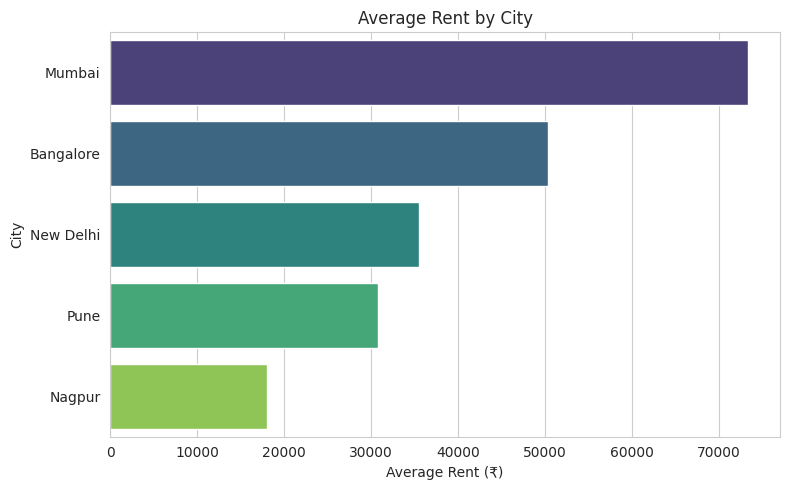

In [14]:
city_avg = clean.groupby("city")["rent"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=city_avg.values, y=city_avg.index, hue=city_avg.index, palette="viridis", legend=False)
plt.xlabel("Average Rent (₹)")
plt.ylabel("City")
plt.title("Average Rent by City")
plt.tight_layout()
plt.savefig("charts/rent_by_city.png", dpi=150, bbox_inches="tight")
plt.show()

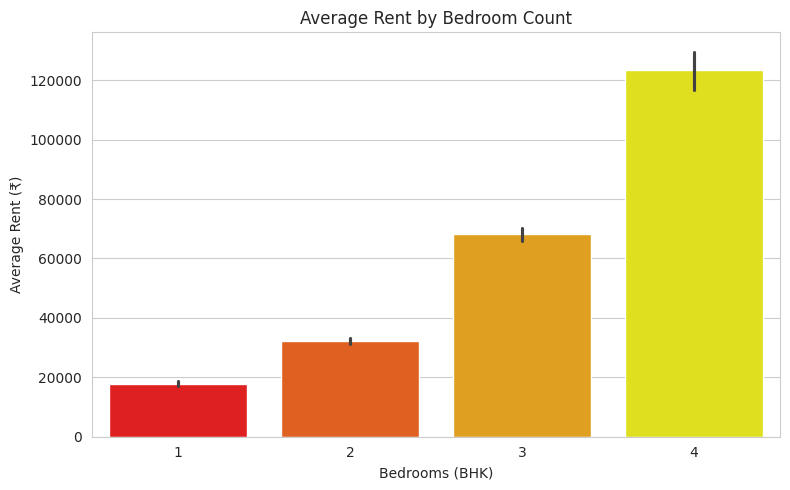

In [15]:
bhk_data = clean[clean["beds"].isin([1, 2, 3, 4])]

plt.figure(figsize=(8, 5))
sns.barplot(x="beds", y="rent", data=bhk_data, hue="beds", palette="autumn", legend=False)
plt.xlabel("Bedrooms (BHK)")
plt.ylabel("Average Rent (₹)")
plt.title("Average Rent by Bedroom Count")
plt.tight_layout()
plt.savefig("charts/rent_by_bedroom_count.png", dpi=150, bbox_inches="tight")
plt.show()

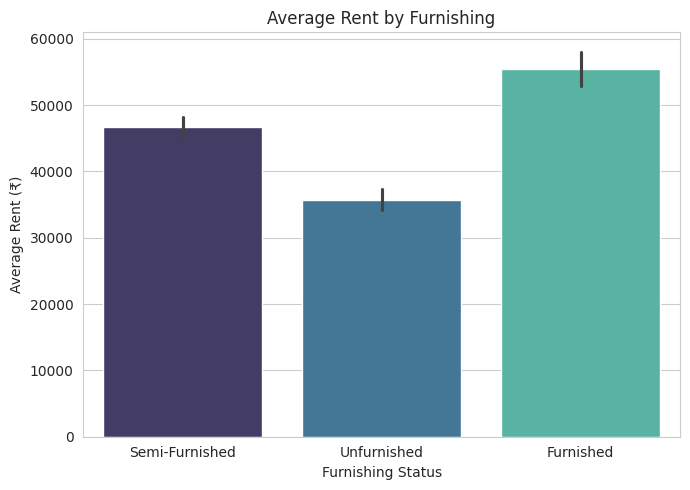

In [16]:
plt.figure(figsize=(7, 5))
sns.barplot(x="furnishing", y="rent", data=clean, hue="furnishing", palette="mako", legend=False)
plt.xlabel("Furnishing Status")
plt.ylabel("Average Rent (₹)")
plt.title("Average Rent by Furnishing")
plt.tight_layout()
plt.savefig("charts/rent_by_furnishing.png", dpi=150, bbox_inches="tight")
plt.show()

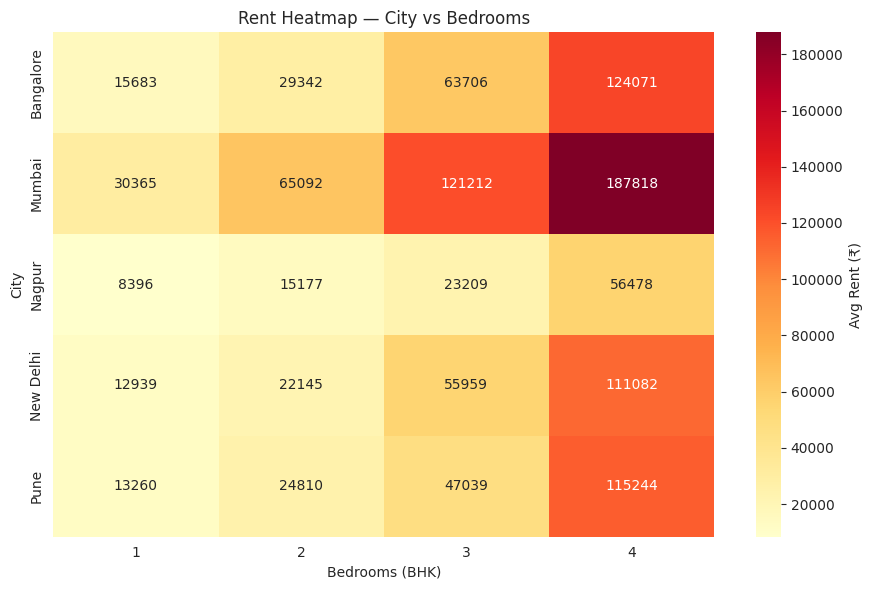

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# build a grid: cities × bedrooms, colored by average rent
bhk_data = clean[clean["beds"].isin([1, 2, 3, 4])]
pivot = bhk_data.pivot_table(values="rent", index="city", columns="beds", aggfunc="mean")

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={"label": "Avg Rent (₹)"})
plt.title("Rent Heatmap — City vs Bedrooms")
plt.xlabel("Bedrooms (BHK)")
plt.ylabel("City")
plt.tight_layout()
plt.savefig("charts/rent_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()